In [4]:
import pandas as pd
from pathlib import Path

In [5]:
RESULTS_DIR = Path("tournament_results_probe_15M")  # change if needed

dfs = []
for f in RESULTS_DIR.glob("*.csv"):
    df = pd.read_csv(f)
    df["source_file"] = f.name
    dfs.append(df)

combined = pd.concat(dfs, ignore_index=True)

print(f"Loaded {len(dfs)} files, {len(combined)} total games")
combined.head()

Loaded 6 files, 1200 total games


,opening_idx,opening_fen,white_policy,black_policy,discrete,result,termination,total_plies,white_budget_remaining,black_budget_remaining,...,white_requested_bucket_100000_count,white_requested_bucket_400000_count,white_requested_bucket_1600000_count,white_token_limited_moves,black_requested_bucket_25000_count,black_requested_bucket_100000_count,black_requested_bucket_400000_count,black_requested_bucket_1600000_count,black_token_limited_moves,source_file
0,0,r1bqk2r/1ppn1ppp/3p1n2/p1b1p3/P1B1P3/2P2N1P/1P...,TokenBucket,FixedUniform,False,1/2-1/2,draw_rule,81,13073618,4277275,...,2,2,0,0,0,0,0,0,0,TokenBucket_vs_FixedUniform_continuous.csv
1,0,r1bqk2r/1ppn1ppp/3p1n2/p1b1p3/P1B1P3/2P2N1P/1P...,FixedUniform,TokenBucket,False,1/2-1/2,draw_adjudication,93,2401048,13098949,...,0,0,0,0,44,0,2,0,0,TokenBucket_vs_FixedUniform_continuous.csv
2,1,rnb1k2r/pp2qppp/3bp3/3n4/2BP4/5N2/PP1B1PPP/RN1...,TokenBucket,FixedUniform,False,1-0,budget_forfeit,113,1229989,0,...,4,1,8,1,0,0,0,0,0,TokenBucket_vs_FixedUniform_continuous.csv
3,1,rnb1k2r/pp2qppp/3bp3/3n4/2BP4/5N2/PP1B1PPP/RN1...,FixedUniform,TokenBucket,False,1-0,resign_adjudication,61,6689970,7787592,...,0,0,0,0,17,4,4,5,5,TokenBucket_vs_FixedUniform_continuous.csv
4,2,r2qk2r/p2bppbp/n1p2np1/1p1p4/2P5/3P1NP1/PPQ1PP...,TokenBucket,FixedUniform,False,1-0,budget_forfeit,113,6070840,0,...,1,3,4,0,0,0,0,0,0,TokenBucket_vs_FixedUniform_continuous.csv


In [6]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 23 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   opening_idx                           1200 non-null   int64 
 1   opening_fen                           1200 non-null   object
 2   white_policy                          1200 non-null   object
 3   black_policy                          1200 non-null   object
 4   discrete                              1200 non-null   bool  
 5   result                                1200 non-null   object
 6   termination                           1200 non-null   object
 7   total_plies                           1200 non-null   int64 
 8   white_budget_remaining                1200 non-null   int64 
 9   black_budget_remaining                1200 non-null   int64 
 10  white_nodes_total                     1200 non-null   int64 
 11  black_nodes_total             

In [7]:
combined.describe()

,opening_idx,total_plies,white_budget_remaining,black_budget_remaining,white_nodes_total,black_nodes_total,white_requested_bucket_25000_count,white_requested_bucket_100000_count,white_requested_bucket_400000_count,white_requested_bucket_1600000_count,white_token_limited_moves,black_requested_bucket_25000_count,black_requested_bucket_100000_count,black_requested_bucket_400000_count,black_requested_bucket_1600000_count,black_token_limited_moves
count,1200.000000,1200.00000,1.200000e+03,1.200000e+03,1.200000e+03,1.200000e+03,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,49.500000,108.63250,5.535052e+06,5.413220e+06,9.464980e+06,9.586807e+06,22.637500,0.920833,1.178333,2.240833,1.013333,22.545833,1.190000,1.333333,2.267500,0.956667
std,28.878105,30.71789,5.240573e+06,5.084325e+06,5.240607e+06,5.084354e+06,25.352055,1.828666,2.056304,4.677899,3.225703,24.989697,2.278865,2.231152,4.426127,3.094528
min,0.000000,17.00000,0.000000e+00,0.000000e+00,2.252410e+05,3.441870e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,24.750000,93.00000,2.560622e+05,2.890008e+05,4.403318e+06,4.728256e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,49.500000,112.00000,3.692499e+06,3.941994e+06,1.130750e+07,1.105801e+07,4.500000,0.000000,0.000000,0.000000,0.000000,3.500000,0.000000,0.000000,0.000000,0.000000
75%,74.250000,120.00000,1.059668e+07,1.027174e+07,1.474394e+07,1.471100e+07,44.000000,1.000000,2.000000,1.000000,0.000000,44.000000,1.000000,2.000000,2.000000,0.000000
max,99.000000,307.00000,1.477476e+07,1.465581e+07,1.500240e+07,1.500137e+07,149.000000,16.000000,16.000000,27.000000,25.000000,146.000000,18.000000,13.000000,24.000000,23.000000


In [8]:
combined["result"].value_counts()

result
1/2-1/2    419
1-0        393
0-1        388
Name: count, dtype: int64

In [9]:
combined["termination"].value_counts()

termination
budget_forfeit         444
draw_adjudication      280
checkmate              176
resign_adjudication    161
draw_rule              139
Name: count, dtype: int64

In [10]:
def tokenbucket_score(df):
    wins = draws = losses = 0
    
    for _, row in df.iterrows():
        if row["result"] == "1/2-1/2":
            draws += 1
        elif row["result"] == "1-0":
            if row["white_policy"] == "TokenBucket":
                wins += 1
            elif row["black_policy"] == "TokenBucket":
                losses += 1
        elif row["result"] == "0-1":
            if row["black_policy"] == "TokenBucket":
                wins += 1
            elif row["white_policy"] == "TokenBucket":
                losses += 1
    
    total = len(df)
    score = wins + 0.5 * draws
    return wins, draws, losses, 100 * score / total

tokenbucket_score(combined) # WDL + %

(290, 419, 491, 41.625)

In [11]:
combined.groupby("discrete").size()

for mode, df in combined.groupby("discrete"):
    print("\nDiscrete =", mode)
    print(tokenbucket_score(df))


Discrete = False
(192, 175, 233, 46.583333333333336)

Discrete = True
(98, 244, 258, 36.666666666666664)


In [12]:
combined["termination"].value_counts(normalize=True)

termination
budget_forfeit         0.370000
draw_adjudication      0.233333
checkmate              0.146667
resign_adjudication    0.134167
draw_rule              0.115833
Name: proportion, dtype: float64

In [13]:
combined[combined["termination"] == "budget_forfeit"].head()

,opening_idx,opening_fen,white_policy,black_policy,discrete,result,termination,total_plies,white_budget_remaining,black_budget_remaining,...,white_requested_bucket_100000_count,white_requested_bucket_400000_count,white_requested_bucket_1600000_count,white_token_limited_moves,black_requested_bucket_25000_count,black_requested_bucket_100000_count,black_requested_bucket_400000_count,black_requested_bucket_1600000_count,black_token_limited_moves,source_file
2,1,rnb1k2r/pp2qppp/3bp3/3n4/2BP4/5N2/PP1B1PPP/RN1...,TokenBucket,FixedUniform,False,1-0,budget_forfeit,113,1229989,0,...,4,1,8,1,0,0,0,0,0,TokenBucket_vs_FixedUniform_continuous.csv
4,2,r2qk2r/p2bppbp/n1p2np1/1p1p4/2P5/3P1NP1/PPQ1PP...,TokenBucket,FixedUniform,False,1-0,budget_forfeit,113,6070840,0,...,1,3,4,0,0,0,0,0,0,TokenBucket_vs_FixedUniform_continuous.csv
10,4,r1bqk2r/ppp2pp1/1bnp3p/3np3/2B1P3/5N1P/PPPPQPP...,TokenBucket,FixedUniform,False,1-0,budget_forfeit,113,13498857,0,...,1,0,0,0,0,0,0,0,0,TokenBucket_vs_FixedUniform_continuous.csv
15,6,rnb1k2r/1pqpbppp/5n2/p3p3/2PP4/P7/NPQ2PPP/R1B1...,FixedUniform,TokenBucket,False,0-1,budget_forfeit,112,0,8721191,...,0,0,0,0,51,2,0,3,0,TokenBucket_vs_FixedUniform_continuous.csv
16,7,rn1qk2r/1pp1bpp1/p4n1p/3p1b2/8/P1NP1N2/1PP1BPP...,TokenBucket,FixedUniform,False,0-1,budget_forfeit,112,0,0,...,1,2,14,9,0,0,0,0,0,TokenBucket_vs_FixedUniform_continuous.csv


In [14]:
combined[["white_nodes_total", "black_nodes_total"]].describe()

,white_nodes_total,black_nodes_total
count,1.200000e+03,1.200000e+03
mean,9.464980e+06,9.586807e+06
std,5.240607e+06,5.084354e+06
min,2.252410e+05,3.441870e+05
25%,4.403318e+06,4.728256e+06
50%,1.130750e+07,1.105801e+07
75%,1.474394e+07,1.471100e+07
max,1.500240e+07,1.500137e+07


In [15]:
def extract_nodes(row):
    if row["white_policy"] == "TokenBucket":
        return row["white_nodes_total"], row["black_nodes_total"]
    else:
        return row["black_nodes_total"], row["white_nodes_total"]

tmp = combined.apply(lambda r: extract_nodes(r), axis=1, result_type="expand")
tmp.columns = ["tb_nodes", "opp_nodes"]

tmp.describe()

,tb_nodes,opp_nodes
count,1.200000e+03,1.200000e+03
mean,7.116891e+06,1.193490e+07
std,5.377617e+06,3.575893e+06
min,2.252410e+05,8.004940e+05
25%,1.851878e+06,1.010602e+07
50%,5.477700e+06,1.330971e+07
75%,1.276054e+07,1.500000e+07
max,1.500240e+07,1.500060e+07


In [16]:
def classify(row):
    if row["result"] == "1/2-1/2":
        return "draw"
    if row["result"] == "1-0":
        return "win" if row["white_policy"] == "TokenBucket" else "loss"
    if row["result"] == "0-1":
        return "win" if row["black_policy"] == "TokenBucket" else "loss"

combined["tb_result"] = combined.apply(classify, axis=1)

combined["tb_result"].value_counts()
pd.crosstab(combined["tb_result"], combined["termination"])

termination,budget_forfeit,checkmate,draw_adjudication,draw_rule,resign_adjudication
tb_result,,,,,
draw,0,0,280,139,0
loss,165,169,0,0,157
win,279,7,0,0,4


In [17]:
for name, df in combined.groupby("source_file"):
    print("\n", name)
    print(tokenbucket_score(df))


 TokenBucket_vs_FixedUniform_continuous.csv
(89, 55, 56, 58.25)

 TokenBucket_vs_FixedUniform_discrete.csv
(6, 104, 90, 29.0)

 TokenBucket_vs_Hyatt_continuous.csv
(102, 37, 61, 60.25)

 TokenBucket_vs_Hyatt_discrete.csv
(82, 56, 62, 55.0)

 TokenBucket_vs_SolakVuckovic_continuous.csv
(1, 83, 116, 21.25)

 TokenBucket_vs_SolakVuckovic_discrete.csv
(10, 84, 106, 26.0)


In [18]:
pd.crosstab(combined["tb_result"], combined["termination"])

termination,budget_forfeit,checkmate,draw_adjudication,draw_rule,resign_adjudication
tb_result,,,,,
draw,0,0,280,139,0
loss,165,169,0,0,157
win,279,7,0,0,4


In [19]:
tmp.groupby(combined["tb_result"]).mean()

,tb_nodes,opp_nodes
tb_result,,
draw,2.164532e+06,1.034479e+07
loss,1.108419e+07,1.158232e+07
win,7.555150e+06,1.482927e+07


In [20]:
combined.groupby(["discrete", "tb_result"]).size()

discrete  tb_result
False     draw         175
          loss         233
          win          192
True      draw         244
          loss         258
          win           98
dtype: int64

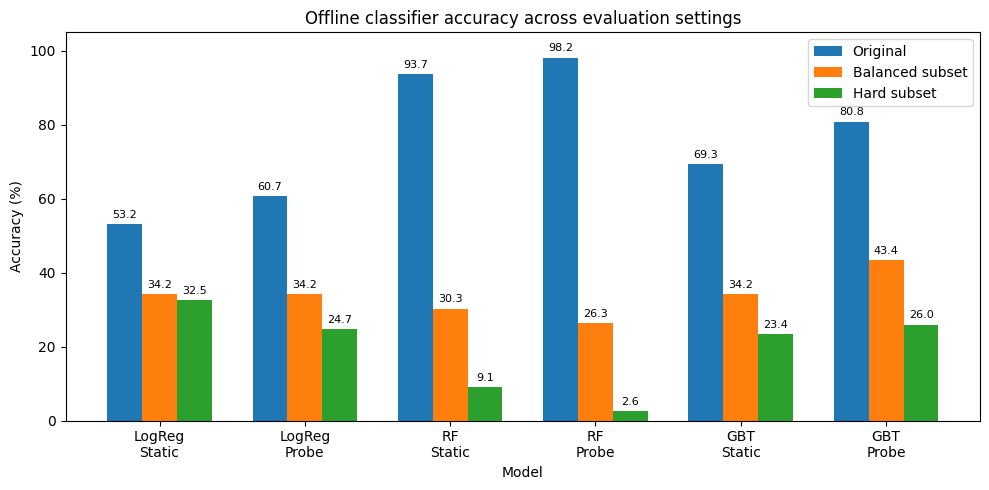

In [21]:
import matplotlib.pyplot as plt
import numpy as np

models = [
    "LogReg\nStatic",
    "LogReg\nProbe",
    "RF\nStatic",
    "RF\nProbe",
    "GBT\nStatic",
    "GBT\nProbe",
]

orig_acc = np.array([
    0.5318,
    0.6073,
    0.9368,
    0.9817,
    0.6927,
    0.8085,
]) * 100

balanced_acc = np.array([
    0.3421,
    0.3421,
    0.3026,
    0.2632,
    0.3421,
    0.4342,
]) * 100

hard_acc = np.array([
    0.3247,
    0.2468,
    0.0909,
    0.0260,
    0.2338,
    0.2597,
]) * 100

x = np.arange(len(models))
width = 0.24

fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(x - width, orig_acc, width, label="Original")
bars2 = ax.bar(x, balanced_acc, width, label="Balanced subset")
bars3 = ax.bar(x + width, hard_acc, width, label="Hard subset")

ax.set_ylabel("Accuracy (%)")
ax.set_xlabel("Model")
ax.set_title("Offline classifier accuracy across evaluation settings")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 105)
ax.legend()

# Optional: add values above bars
for bars in (bars1, bars2, bars3):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.1f}",
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

In [22]:
import re
from pathlib import Path

In [23]:
BASE_DIR = Path(".")
FOLDER_GLOB = "tournament_results_probe_*"

# Order and readable labels for plotting
MATCHUP_ORDER = [
    "TokenBucket_vs_FixedUniform",
    "TokenBucket_vs_SolakVuckovic",
    "TokenBucket_vs_Hyatt",
]

MATCHUP_LABELS = {
    "TokenBucket_vs_FixedUniform": "vs FixedUniform",
    "TokenBucket_vs_SolakVuckovic": "vs SolakVuckovic",
    "TokenBucket_vs_Hyatt": "vs Hyatt",
}

MODE_ORDER = ["discrete", "continuous"]


# ---------- helpers ----------
def parse_budget_label_and_value(folder_name: str):
    """
    Extracts the budget suffix from names like:
      tournament_results_probe_5M
      tournament_results_probe_7.5M
      tournament_results_probe_100M

    Returns:
      (label, numeric_value_for_sorting)
    """
    m = re.search(r"tournament_results_probe_([0-9]+(?:\.[0-9]+)?)M$", folder_name)
    if not m:
        raise ValueError(f"Could not parse budget from folder name: {folder_name}")
    label = f"{m.group(1)}M"
    value = float(m.group(1))
    return label, value


def tokenbucket_score_from_row(row):
    """
    Returns TokenBucket score from one game:
      win = 1.0
      draw = 0.5
      loss = 0.0
      unfinished/other = np.nan
    """
    result = row["result"]
    white = row["white_policy"]
    black = row["black_policy"]

    if result == "1/2-1/2":
        return 0.5
    if result not in {"1-0", "0-1"}:
        return np.nan

    if white == "TokenBucket":
        return 1.0 if result == "1-0" else 0.0
    elif black == "TokenBucket":
        return 1.0 if result == "0-1" else 0.0
    else:
        return np.nan


def wdl_from_scores(scores):
    """
    Given a Series of per-game scores from TokenBucket perspective,
    returns W, D, L counts.
    """
    wins = int((scores == 1.0).sum())
    draws = int((scores == 0.5).sum())
    losses = int((scores == 0.0).sum())
    return wins, draws, losses

In [24]:
rows = []

for folder in sorted(BASE_DIR.glob(FOLDER_GLOB)):
    if not folder.is_dir():
        continue

    budget_label, budget_value = parse_budget_label_and_value(folder.name)

    for csv_path in folder.glob("*.csv"):
        # expected filename format:
        # TokenBucket_vs_FixedUniform_discrete.csv
        stem = csv_path.stem

        matched = False
        for matchup in MATCHUP_ORDER:
            for mode in MODE_ORDER:
                expected = f"{matchup}_{mode}"
                if stem == expected:
                    matched = True

                    df = pd.read_csv(csv_path)
                    df["tb_score"] = df.apply(tokenbucket_score_from_row, axis=1)
                    df_valid = df.dropna(subset=["tb_score"]).copy()

                    scores = df_valid["tb_score"]
                    wins, draws, losses = wdl_from_scores(scores)

                    score_pct = 100.0 * scores.mean() if len(scores) else np.nan

                    rows.append({
                        "budget_label": budget_label,
                        "budget_value": budget_value,
                        "matchup": matchup,
                        "matchup_label": MATCHUP_LABELS[matchup],
                        "mode": mode,
                        "games": len(scores),
                        "wins": wins,
                        "draws": draws,
                        "losses": losses,
                        "score_pct": score_pct,
                        "csv_path": str(csv_path),
                    })

        if not matched:
            print(f"Skipped unexpected file: {csv_path.name}")

summary_df = pd.DataFrame(rows).sort_values(
    ["mode", "matchup", "budget_value"]
).reset_index(drop=True)

summary_df

,budget_label,budget_value,matchup,matchup_label,mode,games,wins,draws,losses,score_pct,csv_path
0,5M,5.0,TokenBucket_vs_FixedUniform,vs FixedUniform,continuous,200,54,65,81,43.25,tournament_results_probe_5M\TokenBucket_vs_Fix...
1,7.5M,7.5,TokenBucket_vs_FixedUniform,vs FixedUniform,continuous,200,64,62,74,47.50,tournament_results_probe_7.5M\TokenBucket_vs_F...
2,10M,10.0,TokenBucket_vs_FixedUniform,vs FixedUniform,continuous,200,77,59,64,53.25,tournament_results_probe_10M\TokenBucket_vs_Fi...
3,12.5M,12.5,TokenBucket_vs_FixedUniform,vs FixedUniform,continuous,200,98,42,60,59.50,tournament_results_probe_12.5M\TokenBucket_vs_...
4,15M,15.0,TokenBucket_vs_FixedUniform,vs FixedUniform,continuous,200,89,55,56,58.25,tournament_results_probe_15M\TokenBucket_vs_Fi...
5,17.5M,17.5,TokenBucket_vs_FixedUniform,vs FixedUniform,continuous,200,91,49,60,57.75,tournament_results_probe_17.5M\TokenBucket_vs_...
6,100M,100.0,TokenBucket_vs_FixedUniform,vs FixedUniform,continuous,200,77,38,85,48.00,tournament_results_probe_100M\TokenBucket_vs_F...
7,5M,5.0,TokenBucket_vs_Hyatt,vs Hyatt,continuous,200,53,71,76,44.25,tournament_results_probe_5M\TokenBucket_vs_Hya...
8,7.5M,7.5,TokenBucket_vs_Hyatt,vs Hyatt,continuous,200,81,61,58,55.75,tournament_results_probe_7.5M\TokenBucket_vs_H...
9,10M,10.0,TokenBucket_vs_Hyatt,vs Hyatt,continuous,200,79,60,61,54.50,tournament_results_probe_10M\TokenBucket_vs_Hy...


In [25]:
summary_df[["budget_label", "mode", "matchup_label", "games", "wins", "draws", "losses", "score_pct"]]

,budget_label,mode,matchup_label,games,wins,draws,losses,score_pct
0,5M,continuous,vs FixedUniform,200,54,65,81,43.25
1,7.5M,continuous,vs FixedUniform,200,64,62,74,47.50
2,10M,continuous,vs FixedUniform,200,77,59,64,53.25
3,12.5M,continuous,vs FixedUniform,200,98,42,60,59.50
4,15M,continuous,vs FixedUniform,200,89,55,56,58.25
5,17.5M,continuous,vs FixedUniform,200,91,49,60,57.75
6,100M,continuous,vs FixedUniform,200,77,38,85,48.00
7,5M,continuous,vs Hyatt,200,53,71,76,44.25
8,7.5M,continuous,vs Hyatt,200,81,61,58,55.75
9,10M,continuous,vs Hyatt,200,79,60,61,54.50


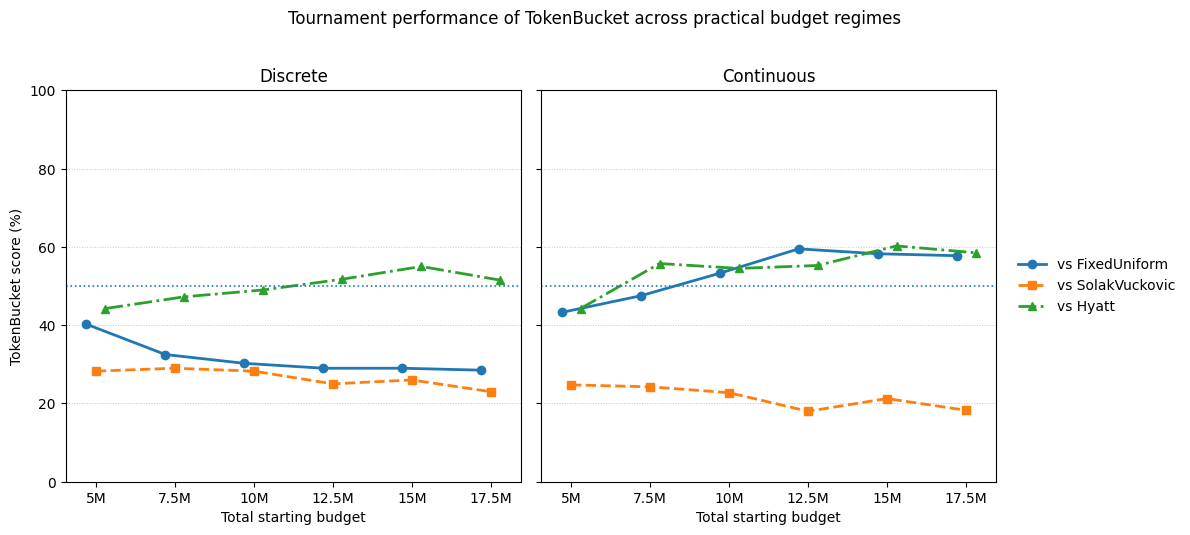

In [28]:
plot_df = summary_df[summary_df["budget_value"] < 100].copy()

# Keep budgets in the intended order
budget_order = sorted(plot_df["budget_value"].unique())
budget_labels = [f"{x:g}M" for x in budget_order]
x_base = np.arange(len(budget_order))

# Small offsets so lines/markers do not sit exactly on top of each other
offset_map = {
    "TokenBucket_vs_FixedUniform": -0.12,
    "TokenBucket_vs_SolakVuckovic": 0.00,
    "TokenBucket_vs_Hyatt": 0.12,
}

marker_map = {
    "TokenBucket_vs_FixedUniform": "o",
    "TokenBucket_vs_SolakVuckovic": "s",
    "TokenBucket_vs_Hyatt": "^",
}

linestyle_map = {
    "TokenBucket_vs_FixedUniform": "-",
    "TokenBucket_vs_SolakVuckovic": "--",
    "TokenBucket_vs_Hyatt": "-.",
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), sharey=True)

for ax, mode in zip(axes, MODE_ORDER):
    mode_df = plot_df[plot_df["mode"] == mode].copy()

    for matchup in MATCHUP_ORDER:
        sub = mode_df[mode_df["matchup"] == matchup].sort_values("budget_value")

        # Map actual budgets to categorical x positions
        x = np.array([budget_order.index(v) for v in sub["budget_value"]], dtype=float)
        x = x + offset_map[matchup]

        y = sub["score_pct"].to_numpy()

        ax.plot(
            x,
            y,
            marker=marker_map[matchup],
            linestyle=linestyle_map[matchup],
            linewidth=2,
            markersize=6,
            label=MATCHUP_LABELS[matchup],
        )

    ax.axhline(50.0, linestyle=":", linewidth=1.2)
    ax.set_title(mode.capitalize())
    ax.set_xlabel("Total starting budget")
    ax.set_xticks(x_base)
    ax.set_xticklabels(budget_labels)
    ax.grid(axis="y", linestyle=":", linewidth=0.7, alpha=0.7)

axes[0].set_ylabel("TokenBucket score (%)")
axes[0].set_ylim(0, 100)

# Put legend outside so it doesn't cover lines
axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

fig.suptitle("Tournament performance of TokenBucket across practical budget regimes", y=1.02)
plt.tight_layout()
plt.show()

In [29]:
display_table = summary_df.copy()
display_table["WDL"] = display_table.apply(
    lambda r: f"+{r['wins']} ={r['draws']} -{r['losses']}", axis=1
)
display_table["Score (%)"] = display_table["score_pct"].round(1)

display_table = display_table[
    ["budget_label", "mode", "matchup_label", "WDL", "Score (%)"]
].sort_values(["mode", "budget_label"])

display_table

,budget_label,mode,matchup_label,WDL,Score (%)
6,100M,continuous,vs FixedUniform,+77 =38 -85,48.0
13,100M,continuous,vs Hyatt,+76 =38 -86,47.5
20,100M,continuous,vs SolakVuckovic,+1 =59 -140,15.2
2,10M,continuous,vs FixedUniform,+77 =59 -64,53.2
9,10M,continuous,vs Hyatt,+79 =60 -61,54.5
16,10M,continuous,vs SolakVuckovic,+4 =83 -113,22.8
3,12.5M,continuous,vs FixedUniform,+98 =42 -60,59.5
10,12.5M,continuous,vs Hyatt,+87 =47 -66,55.2
17,12.5M,continuous,vs SolakVuckovic,+2 =68 -130,18.0
4,15M,continuous,vs FixedUniform,+89 =55 -56,58.2


In [30]:
import re

BASE_DIR = Path(".")
FOLDER_GLOB = "tournament_results_probe_*"

MATCHUP_ORDER = [
    "TokenBucket_vs_FixedUniform",
    "TokenBucket_vs_SolakVuckovic",
    "TokenBucket_vs_Hyatt",
]

MODE_ORDER = ["discrete", "continuous"]

MATCHUP_LABELS = {
    "TokenBucket_vs_FixedUniform": "vs FixedUniform",
    "TokenBucket_vs_SolakVuckovic": "vs SolakVuckovic",
    "TokenBucket_vs_Hyatt": "vs Hyatt",
}

def parse_budget_label_and_value(folder_name: str):
    m = re.search(r"tournament_results_probe_([0-9]+(?:\.[0-9]+)?)M$", folder_name)
    if not m:
        raise ValueError(f"Could not parse budget from folder name: {folder_name}")
    label = f"{m.group(1)}M"
    value = float(m.group(1))
    return label, value

In [33]:
all_parts = []

for folder in sorted(BASE_DIR.glob(FOLDER_GLOB)):
    if not folder.is_dir():
        continue

    budget_label, budget_value = parse_budget_label_and_value(folder.name)

    for csv_path in folder.glob("*.csv"):
        stem = csv_path.stem

        matched = False
        for matchup in MATCHUP_ORDER:
            for mode in MODE_ORDER:
                expected = f"{matchup}_{mode}"
                if stem == expected:
                    matched = True
                    df = pd.read_csv(csv_path).copy()
                    df["budget_label"] = budget_label
                    df["budget_value"] = budget_value
                    df["matchup"] = matchup
                    df["matchup_label"] = MATCHUP_LABELS[matchup]
                    df["mode"] = mode
                    df["source_csv"] = csv_path.name
                    all_parts.append(df)

        if not matched:
            print(f"Skipped unexpected file: {csv_path}")

games_df = pd.concat(all_parts, ignore_index=True)
games_df.head()

,opening_idx,opening_fen,white_policy,black_policy,discrete,result,termination,total_plies,white_budget_remaining,black_budget_remaining,...,black_requested_bucket_100000_count,black_requested_bucket_400000_count,black_requested_bucket_1600000_count,black_token_limited_moves,budget_label,budget_value,matchup,matchup_label,mode,source_csv
0,0,r1bqk2r/1ppn1ppp/3p1n2/p1b1p3/P1B1P3/2P2N1P/1P...,TokenBucket,FixedUniform,False,1/2-1/2,draw_adjudication,97,97723428,14248668,...,0,0,0,0,100M,100.0,TokenBucket_vs_FixedUniform,vs FixedUniform,continuous,TokenBucket_vs_FixedUniform_continuous.csv
1,0,r1bqk2r/1ppn1ppp/3p1n2/p1b1p3/P1B1P3/2P2N1P/1P...,FixedUniform,TokenBucket,False,0-1,budget_forfeit,112,0,90870319,...,4,3,4,0,100M,100.0,TokenBucket_vs_FixedUniform,vs FixedUniform,continuous,TokenBucket_vs_FixedUniform_continuous.csv
2,1,rnb1k2r/pp2qppp/3bp3/3n4/2BP4/5N2/PP1B1PPP/RN1...,TokenBucket,FixedUniform,False,1-0,budget_forfeit,113,98123311,0,...,0,0,0,0,100M,100.0,TokenBucket_vs_FixedUniform,vs FixedUniform,continuous,TokenBucket_vs_FixedUniform_continuous.csv
3,1,rnb1k2r/pp2qppp/3bp3/3n4/2BP4/5N2/PP1B1PPP/RN1...,FixedUniform,TokenBucket,False,1-0,resign_adjudication,107,3527860,73463430,...,2,8,14,0,100M,100.0,TokenBucket_vs_FixedUniform,vs FixedUniform,continuous,TokenBucket_vs_FixedUniform_continuous.csv
4,2,r2qk2r/p2bppbp/n1p2np1/1p1p4/2P5/3P1NP1/PPQ1PP...,TokenBucket,FixedUniform,False,0-1,checkmate,88,96614622,26501577,...,0,0,0,0,100M,100.0,TokenBucket_vs_FixedUniform,vs FixedUniform,continuous,TokenBucket_vs_FixedUniform_continuous.csv


In [34]:
overall_term = (
    games_df["termination"]
    .value_counts(dropna=False)
    .rename_axis("termination")
    .reset_index(name="games")
)

overall_term["pct"] = 100 * overall_term["games"] / overall_term["games"].sum()
overall_term

,termination,games,pct
0,budget_forfeit,3008,35.809524
1,draw_adjudication,2033,24.202381
2,checkmate,1307,15.559524
3,resign_adjudication,1074,12.785714
4,draw_rule,966,11.500000
5,stalemate,12,0.142857


In [35]:
term_breakdown = (
    games_df
    .groupby(["budget_label", "budget_value", "mode", "matchup_label", "termination"])
    .size()
    .reset_index(name="games")
    .sort_values(["mode", "matchup_label", "budget_value", "termination"])
)

term_breakdown.head(20)

,budget_label,budget_value,mode,matchup_label,termination,games
158,5M,5.0,continuous,vs FixedUniform,budget_forfeit,114
159,5M,5.0,continuous,vs FixedUniform,checkmate,14
160,5M,5.0,continuous,vs FixedUniform,draw_adjudication,49
161,5M,5.0,continuous,vs FixedUniform,draw_rule,16
162,5M,5.0,continuous,vs FixedUniform,resign_adjudication,7
189,7.5M,7.5,continuous,vs FixedUniform,budget_forfeit,98
190,7.5M,7.5,continuous,vs FixedUniform,checkmate,20
191,7.5M,7.5,continuous,vs FixedUniform,draw_adjudication,39
192,7.5M,7.5,continuous,vs FixedUniform,draw_rule,22
193,7.5M,7.5,continuous,vs FixedUniform,resign_adjudication,20


In [36]:
term_pivot = (
    term_breakdown
    .pivot_table(
        index=["budget_label", "budget_value", "mode", "matchup_label"],
        columns="termination",
        values="games",
        fill_value=0,
        aggfunc="sum",
    )
    .reset_index()
    .sort_values(["mode", "matchup_label", "budget_value"])
)

term_pivot

termination,budget_label,budget_value,mode,matchup_label,budget_forfeit,checkmate,draw_adjudication,draw_rule,resign_adjudication,stalemate
30,5M,5.0,continuous,vs FixedUniform,114,14,49,16,7,0
36,7.5M,7.5,continuous,vs FixedUniform,98,20,39,22,20,1
6,10M,10.0,continuous,vs FixedUniform,98,22,30,29,21,0
12,12.5M,12.5,continuous,vs FixedUniform,108,21,23,19,29,0
18,15M,15.0,continuous,vs FixedUniform,96,21,34,21,28,0
24,17.5M,17.5,continuous,vs FixedUniform,95,31,26,23,25,0
0,100M,100.0,continuous,vs FixedUniform,77,45,24,13,40,1
31,5M,5.0,continuous,vs Hyatt,107,16,47,24,6,0
37,7.5M,7.5,continuous,vs Hyatt,106,23,40,21,10,0
7,10M,10.0,continuous,vs Hyatt,100,24,35,25,16,0


In [37]:
termination_cols = [c for c in term_pivot.columns if c not in ["budget_label", "budget_value", "mode", "matchup_label"]]

term_pct = term_pivot.copy()
row_totals = term_pct[termination_cols].sum(axis=1)

for c in termination_cols:
    term_pct[c] = 100 * term_pct[c] / row_totals

term_pct

termination,budget_label,budget_value,mode,matchup_label,budget_forfeit,checkmate,draw_adjudication,draw_rule,resign_adjudication,stalemate
30,5M,5.0,continuous,vs FixedUniform,57.0,7.0,24.5,8.0,3.5,0.0
36,7.5M,7.5,continuous,vs FixedUniform,49.0,10.0,19.5,11.0,10.0,0.5
6,10M,10.0,continuous,vs FixedUniform,49.0,11.0,15.0,14.5,10.5,0.0
12,12.5M,12.5,continuous,vs FixedUniform,54.0,10.5,11.5,9.5,14.5,0.0
18,15M,15.0,continuous,vs FixedUniform,48.0,10.5,17.0,10.5,14.0,0.0
24,17.5M,17.5,continuous,vs FixedUniform,47.5,15.5,13.0,11.5,12.5,0.0
0,100M,100.0,continuous,vs FixedUniform,38.5,22.5,12.0,6.5,20.0,0.5
31,5M,5.0,continuous,vs Hyatt,53.5,8.0,23.5,12.0,3.0,0.0
37,7.5M,7.5,continuous,vs Hyatt,53.0,11.5,20.0,10.5,5.0,0.0
7,10M,10.0,continuous,vs Hyatt,50.0,12.0,17.5,12.5,8.0,0.0


In [38]:
budget_forfeit_table = (
    games_df.assign(is_budget_forfeit=(games_df["termination"] == "budget_forfeit").astype(int))
    .groupby(["budget_label", "budget_value", "mode", "matchup_label"])["is_budget_forfeit"]
    .agg(["sum", "count"])
    .reset_index()
    .rename(columns={"sum": "budget_forfeits", "count": "games"})
    .sort_values(["mode", "matchup_label", "budget_value"])
)

budget_forfeit_table["budget_forfeit_pct"] = 100 * budget_forfeit_table["budget_forfeits"] / budget_forfeit_table["games"]
budget_forfeit_table

,budget_label,budget_value,mode,matchup_label,budget_forfeits,games,budget_forfeit_pct
30,5M,5.0,continuous,vs FixedUniform,114,200,57.0
36,7.5M,7.5,continuous,vs FixedUniform,98,200,49.0
6,10M,10.0,continuous,vs FixedUniform,98,200,49.0
12,12.5M,12.5,continuous,vs FixedUniform,108,200,54.0
18,15M,15.0,continuous,vs FixedUniform,96,200,48.0
24,17.5M,17.5,continuous,vs FixedUniform,95,200,47.5
0,100M,100.0,continuous,vs FixedUniform,77,200,38.5
31,5M,5.0,continuous,vs Hyatt,107,200,53.5
37,7.5M,7.5,continuous,vs Hyatt,106,200,53.0
7,10M,10.0,continuous,vs Hyatt,100,200,50.0


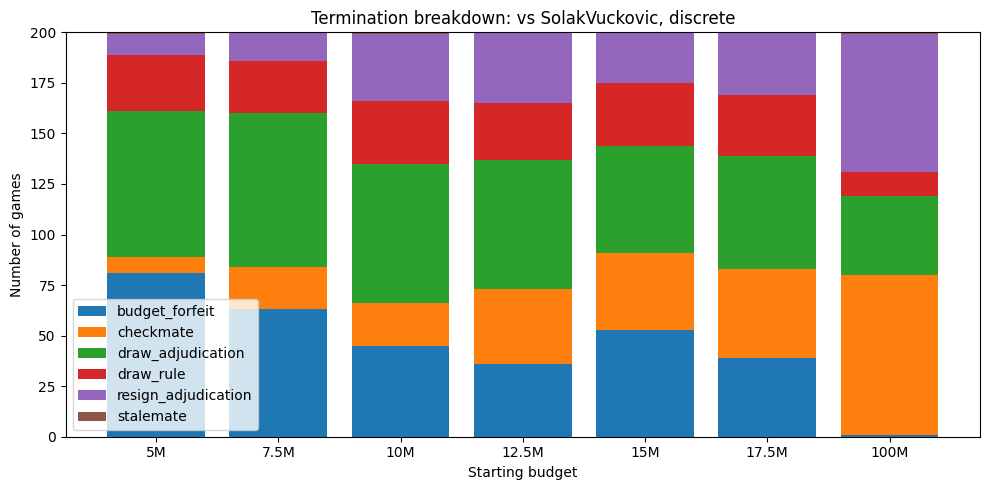

In [42]:
TARGET_MODE = "discrete"
TARGET_MATCHUP = "vs SolakVuckovic"

plot_df = (
    term_breakdown[
        (term_breakdown["mode"] == TARGET_MODE) &
        (term_breakdown["matchup_label"] == TARGET_MATCHUP)
    ]
    .pivot_table(
        index=["budget_label", "budget_value"],
        columns="termination",
        values="games",
        fill_value=0,
        aggfunc="sum"
    )
    .reset_index()
    .sort_values("budget_value")
)

termination_plot_cols = [c for c in plot_df.columns if c not in ["budget_label", "budget_value"]]

x = np.arange(len(plot_df))
bottom = np.zeros(len(plot_df))

plt.figure(figsize=(10, 5))

for col in termination_plot_cols:
    vals = plot_df[col].to_numpy()
    plt.bar(x, vals, bottom=bottom, label=col)
    bottom += vals

plt.xticks(x, plot_df["budget_label"])
plt.xlabel("Starting budget")
plt.ylabel("Number of games")
plt.title(f"Termination breakdown: {TARGET_MATCHUP}, {TARGET_MODE}")
plt.legend()
plt.tight_layout()
plt.show()

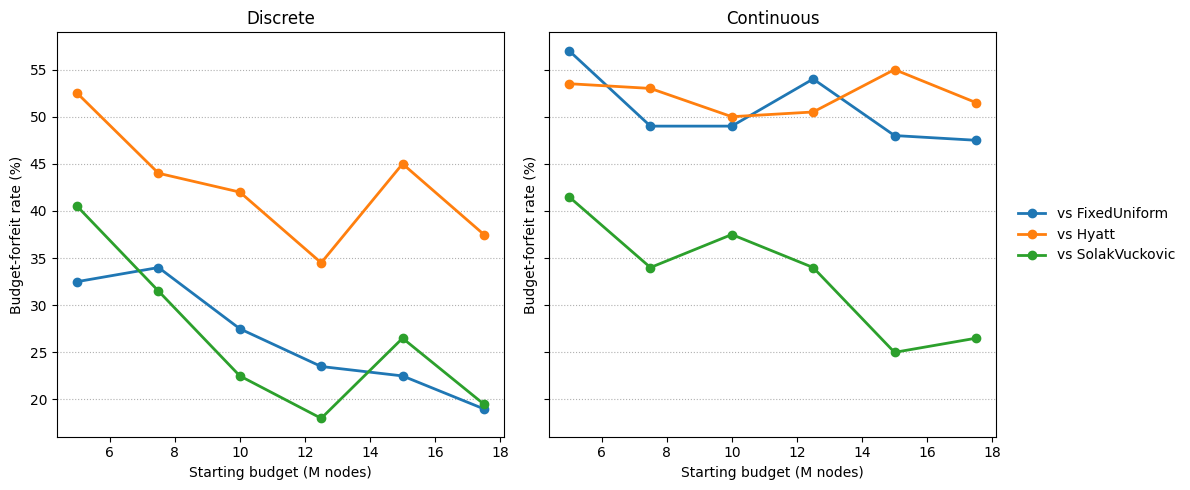

In [40]:
plot_df = budget_forfeit_table[budget_forfeit_table["budget_value"] < 100].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, mode in zip(axes, MODE_ORDER):
    sub_mode = plot_df[plot_df["mode"] == mode]

    for matchup_label in sub_mode["matchup_label"].unique():
        sub = sub_mode[sub_mode["matchup_label"] == matchup_label].sort_values("budget_value")
        ax.plot(
            sub["budget_value"],
            sub["budget_forfeit_pct"],
            marker="o",
            linewidth=2,
            label=matchup_label,
        )

    ax.set_title(mode.capitalize())
    ax.set_xlabel("Starting budget (M nodes)")
    ax.set_ylabel("Budget-forfeit rate (%)")
    ax.grid(axis="y", linestyle=":")

axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.tight_layout()
plt.show()

In [41]:
important_terms = ["budget_forfeit", "draw_adjudication", "resign_adjudication", "checkmate"]

important_term_table = term_pivot.copy()
for col in important_terms:
    if col not in important_term_table.columns:
        important_term_table[col] = 0

important_term_table = important_term_table[
    ["budget_label", "budget_value", "mode", "matchup_label"] + important_terms
].sort_values(["mode", "matchup_label", "budget_value"])

important_term_table

termination,budget_label,budget_value,mode,matchup_label,budget_forfeit,draw_adjudication,resign_adjudication,checkmate
30,5M,5.0,continuous,vs FixedUniform,114,49,7,14
36,7.5M,7.5,continuous,vs FixedUniform,98,39,20,20
6,10M,10.0,continuous,vs FixedUniform,98,30,21,22
12,12.5M,12.5,continuous,vs FixedUniform,108,23,29,21
18,15M,15.0,continuous,vs FixedUniform,96,34,28,21
24,17.5M,17.5,continuous,vs FixedUniform,95,26,25,31
0,100M,100.0,continuous,vs FixedUniform,77,24,40,45
31,5M,5.0,continuous,vs Hyatt,107,47,6,16
37,7.5M,7.5,continuous,vs Hyatt,106,40,10,23
7,10M,10.0,continuous,vs Hyatt,100,35,16,24


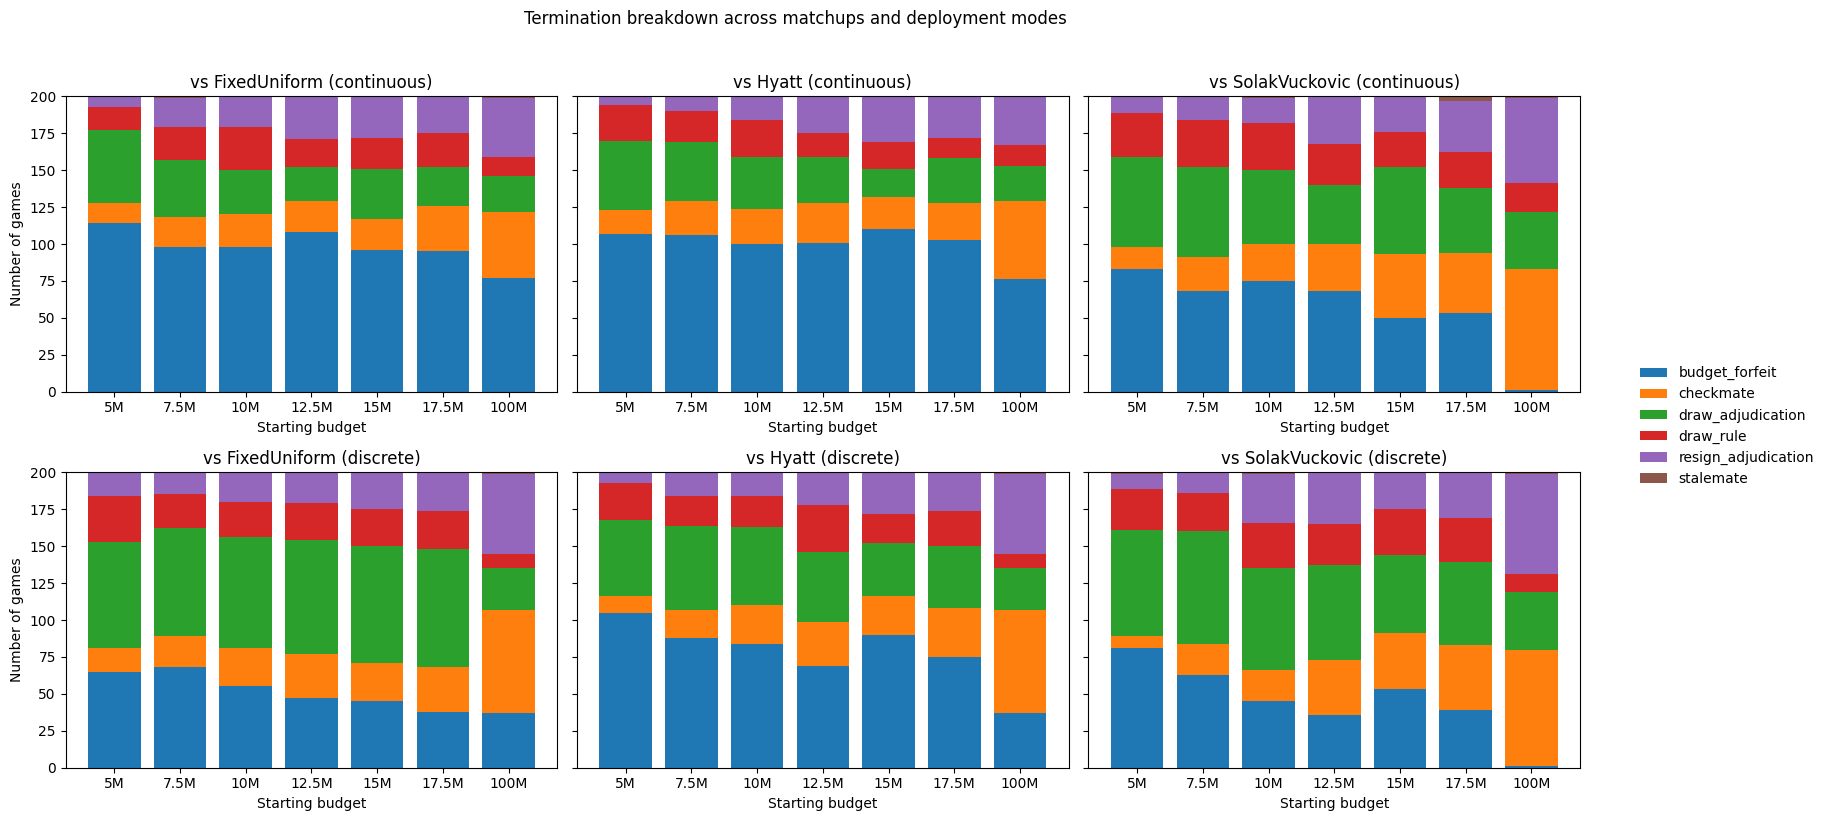

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# Optional: exclude the 100M outlier from appendix plots
EXCLUDE_100M = False

plot_source = term_breakdown.copy()
if EXCLUDE_100M:
    plot_source = plot_source[plot_source["budget_value"] < 100].copy()

mode_order = ["continuous", "discrete"]
matchup_order = ["vs FixedUniform", "vs Hyatt", "vs SolakVuckovic"]

# Collect all termination categories present so colors/legend stay consistent
all_terminations = sorted(plot_source["termination"].dropna().unique())

fig, axes = plt.subplots(
    nrows=len(mode_order),
    ncols=len(matchup_order),
    figsize=(16, 8),
    sharey=True
)

for i, mode in enumerate(mode_order):
    for j, matchup in enumerate(matchup_order):
        ax = axes[i, j]

        plot_df = (
            plot_source[
                (plot_source["mode"] == mode) &
                (plot_source["matchup_label"] == matchup)
            ]
            .pivot_table(
                index=["budget_label", "budget_value"],
                columns="termination",
                values="games",
                fill_value=0,
                aggfunc="sum"
            )
            .reset_index()
            .sort_values("budget_value")
        )

        x = np.arange(len(plot_df))
        bottom = np.zeros(len(plot_df))

        for term in all_terminations:
            vals = plot_df[term].to_numpy() if term in plot_df.columns else np.zeros(len(plot_df))
            ax.bar(x, vals, bottom=bottom, label=term)
            bottom += vals

        ax.set_xticks(x)
        ax.set_xticklabels(plot_df["budget_label"], rotation=0)
        ax.set_xlabel("Starting budget")

        if j == 0:
            ax.set_ylabel("Number of games")

        ax.set_title(f"{matchup} ({mode})")

# Put one shared legend for the whole figure
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

fig.suptitle("Termination breakdown across matchups and deployment modes", y=1.02)
plt.tight_layout()
plt.show()

In [44]:
def tokenbucket_outcome(row):
    result = row["result"]

    if result == "1/2-1/2":
        return "draw"
    if result not in {"1-0", "0-1"}:
        return "unfinished"

    if row["white_policy"] == "TokenBucket":
        return "win" if result == "1-0" else "loss"
    elif row["black_policy"] == "TokenBucket":
        return "win" if result == "0-1" else "loss"
    else:
        return "not_tokenbucket_game"

games_df["tb_outcome"] = games_df.apply(tokenbucket_outcome, axis=1)

In [45]:
tb_term_outcome = (
    games_df
    .groupby(["budget_label", "budget_value", "mode", "matchup_label", "tb_outcome", "termination"])
    .size()
    .reset_index(name="games")
    .sort_values(["mode", "matchup_label", "budget_value", "tb_outcome", "termination"])
)

tb_term_outcome

,budget_label,budget_value,mode,matchup_label,tb_outcome,termination,games
205,5M,5.0,continuous,vs FixedUniform,draw,draw_adjudication,49
206,5M,5.0,continuous,vs FixedUniform,draw,draw_rule,16
207,5M,5.0,continuous,vs FixedUniform,loss,budget_forfeit,61
208,5M,5.0,continuous,vs FixedUniform,loss,checkmate,14
209,5M,5.0,continuous,vs FixedUniform,loss,resign_adjudication,6
...,...,...,...,...,...,...,...
33,100M,100.0,discrete,vs SolakVuckovic,draw,stalemate,1
34,100M,100.0,discrete,vs SolakVuckovic,loss,checkmate,79
35,100M,100.0,discrete,vs SolakVuckovic,loss,resign_adjudication,67
36,100M,100.0,discrete,vs SolakVuckovic,win,budget_forfeit,1


In [50]:
tb_term_outcome_pivot = (
    tb_term_outcome
    .pivot_table(
        index=["budget_label", "budget_value", "mode", "matchup_label", "tb_outcome"],
        columns="termination",
        values="games",
        fill_value=0,
        aggfunc="sum",
    )
    .reset_index()
    .sort_values(["mode", "matchup_label", "budget_value", "tb_outcome"])
)

tb_term_outcome_pivot

termination,budget_label,budget_value,mode,matchup_label,tb_outcome,budget_forfeit,checkmate,draw_adjudication,draw_rule,resign_adjudication,stalemate
90,5M,5.0,continuous,vs FixedUniform,draw,0,0,49,16,0,0
91,5M,5.0,continuous,vs FixedUniform,loss,61,14,0,0,6,0
92,5M,5.0,continuous,vs FixedUniform,win,53,0,0,0,1,0
108,7.5M,7.5,continuous,vs FixedUniform,draw,0,0,39,22,0,1
109,7.5M,7.5,continuous,vs FixedUniform,loss,34,20,0,0,20,0
...,...,...,...,...,...,...,...,...,...,...,...
88,17.5M,17.5,discrete,vs SolakVuckovic,loss,38,42,0,0,31,0
89,17.5M,17.5,discrete,vs SolakVuckovic,win,1,2,0,0,0,0
15,100M,100.0,discrete,vs SolakVuckovic,draw,0,0,39,12,0,1
16,100M,100.0,discrete,vs SolakVuckovic,loss,0,79,0,0,67,0


In [51]:
loss_breakdown = tb_term_outcome_pivot[tb_term_outcome_pivot["tb_outcome"] == "loss"].copy()
loss_breakdown.drop(["tb_outcome", "draw_adjudication", "draw_rule", "resign_adjudication", "stalemate"], axis=1)

termination,budget_label,budget_value,mode,matchup_label,budget_forfeit,checkmate
91,5M,5.0,continuous,vs FixedUniform,61,14
109,7.5M,7.5,continuous,vs FixedUniform,34,20
19,10M,10.0,continuous,vs FixedUniform,22,22
37,12.5M,12.5,continuous,vs FixedUniform,11,20
55,15M,15.0,continuous,vs FixedUniform,8,21
73,17.5M,17.5,continuous,vs FixedUniform,4,31
1,100M,100.0,continuous,vs FixedUniform,0,45
94,5M,5.0,continuous,vs Hyatt,55,16
112,7.5M,7.5,continuous,vs Hyatt,26,22
22,10M,10.0,continuous,vs Hyatt,21,24


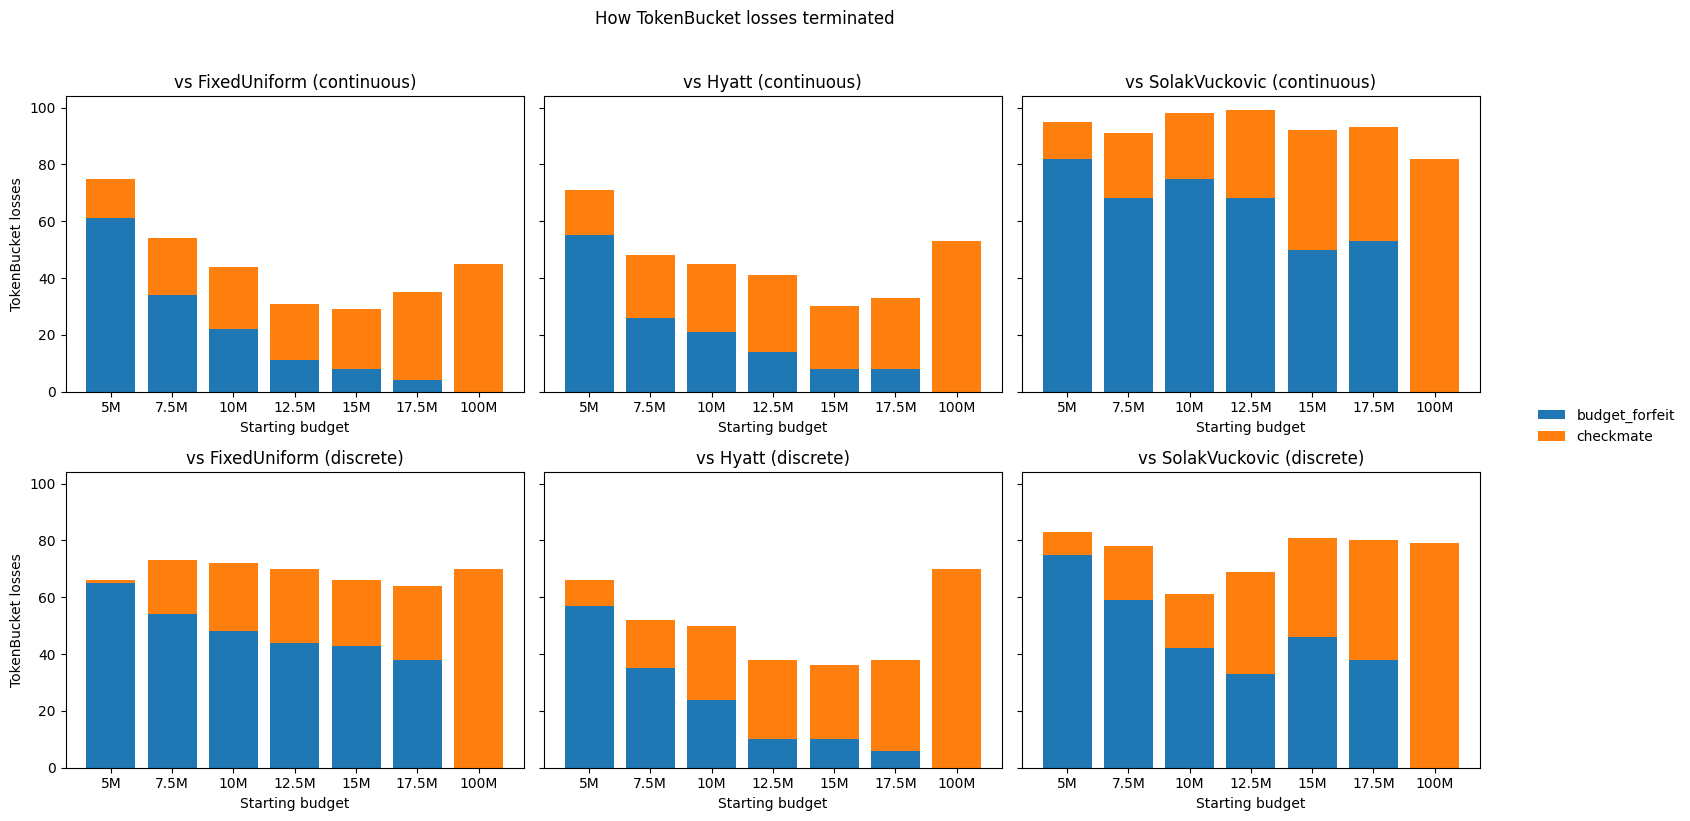

In [52]:
# Start from your filtered dataframe
plot_df = tb_term_outcome_pivot[tb_term_outcome_pivot["tb_outcome"] == "loss"].copy()

# Drop columns you do not want to show
plot_df = plot_df.drop(
    columns=["tb_outcome", "draw_adjudication", "draw_rule", "resign_adjudication", "stalemate"],
    errors="ignore"
)

mode_order = ["continuous", "discrete"]
matchup_order = ["vs FixedUniform", "vs Hyatt", "vs SolakVuckovic"]

# Remaining termination columns after metadata
meta_cols = ["budget_label", "budget_value", "mode", "matchup_label"]
termination_cols = [c for c in plot_df.columns if c not in meta_cols]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)

for i, mode in enumerate(mode_order):
    for j, matchup in enumerate(matchup_order):
        ax = axes[i, j]

        sub = (
            plot_df[
                (plot_df["mode"] == mode) &
                (plot_df["matchup_label"] == matchup)
            ]
            .sort_values("budget_value")
        )

        x = np.arange(len(sub))
        bottom = np.zeros(len(sub))

        for term in termination_cols:
            vals = sub[term].to_numpy()
            ax.bar(x, vals, bottom=bottom, label=term)
            bottom += vals

        ax.set_xticks(x)
        ax.set_xticklabels(sub["budget_label"])
        ax.set_title(f"{matchup} ({mode})")
        ax.set_xlabel("Starting budget")

        if j == 0:
            ax.set_ylabel("TokenBucket losses")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

fig.suptitle("How TokenBucket losses terminated", y=1.02)
plt.tight_layout()
plt.show()

In [53]:
def extract_tb_metrics(row):
    if row["white_policy"] == "TokenBucket":
        return pd.Series({
            "tb_side": "white",
            "tb_token_limited_moves": row["white_token_limited_moves"],
            "tb_req_25k": row["white_requested_bucket_25000_count"],
            "tb_req_100k": row["white_requested_bucket_100000_count"],
            "tb_req_400k": row["white_requested_bucket_400000_count"],
            "tb_req_1600k": row["white_requested_bucket_1600000_count"],
            "tb_budget_remaining": row["white_budget_remaining"],
            "tb_nodes_total": row["white_nodes_total"],
        })
    elif row["black_policy"] == "TokenBucket":
        return pd.Series({
            "tb_side": "black",
            "tb_token_limited_moves": row["black_token_limited_moves"],
            "tb_req_25k": row["black_requested_bucket_25000_count"],
            "tb_req_100k": row["black_requested_bucket_100000_count"],
            "tb_req_400k": row["black_requested_bucket_400000_count"],
            "tb_req_1600k": row["black_requested_bucket_1600000_count"],
            "tb_budget_remaining": row["black_budget_remaining"],
            "tb_nodes_total": row["black_nodes_total"],
        })
    else:
        return pd.Series({
            "tb_side": None,
            "tb_token_limited_moves": np.nan,
            "tb_req_25k": np.nan,
            "tb_req_100k": np.nan,
            "tb_req_400k": np.nan,
            "tb_req_1600k": np.nan,
            "tb_budget_remaining": np.nan,
            "tb_nodes_total": np.nan,
        })

tb_metrics = games_df.apply(extract_tb_metrics, axis=1)
games_tb = pd.concat([games_df, tb_metrics], axis=1)

games_tb.head()

,opening_idx,opening_fen,white_policy,black_policy,discrete,result,termination,total_plies,white_budget_remaining,black_budget_remaining,...,source_csv,tb_outcome,tb_side,tb_token_limited_moves,tb_req_25k,tb_req_100k,tb_req_400k,tb_req_1600k,tb_budget_remaining,tb_nodes_total
0,0,r1bqk2r/1ppn1ppp/3p1n2/p1b1p3/P1B1P3/2P2N1P/1P...,TokenBucket,FixedUniform,False,1/2-1/2,draw_adjudication,97,97723428,14248668,...,TokenBucket_vs_FixedUniform_continuous.csv,draw,white,0,43,4,2,0,97723428,2276572
1,0,r1bqk2r/1ppn1ppp/3p1n2/p1b1p3/P1B1P3/2P2N1P/1P...,FixedUniform,TokenBucket,False,0-1,budget_forfeit,112,0,90870319,...,TokenBucket_vs_FixedUniform_continuous.csv,win,black,0,45,4,3,4,90870319,9129681
2,1,rnb1k2r/pp2qppp/3bp3/3n4/2BP4/5N2/PP1B1PPP/RN1...,TokenBucket,FixedUniform,False,1-0,budget_forfeit,113,98123311,0,...,TokenBucket_vs_FixedUniform_continuous.csv,win,white,0,55,1,1,0,98123311,1876689
3,1,rnb1k2r/pp2qppp/3bp3/3n4/2BP4/5N2/PP1B1PPP/RN1...,FixedUniform,TokenBucket,False,1-0,resign_adjudication,107,3527860,73463430,...,TokenBucket_vs_FixedUniform_continuous.csv,loss,black,0,29,2,8,14,73463430,26536570
4,2,r2qk2r/p2bppbp/n1p2np1/1p1p4/2P5/3P1NP1/PPQ1PP...,TokenBucket,FixedUniform,False,0-1,checkmate,88,96614622,26501577,...,TokenBucket_vs_FixedUniform_continuous.csv,loss,white,0,41,0,2,1,96614622,3385378


In [54]:
def tokenbucket_outcome(row):
    result = row["result"]

    if result == "1/2-1/2":
        return "draw"
    if result not in {"1-0", "0-1"}:
        return "unfinished"

    if row["white_policy"] == "TokenBucket":
        return "win" if result == "1-0" else "loss"
    elif row["black_policy"] == "TokenBucket":
        return "win" if result == "0-1" else "loss"
    else:
        return "not_tokenbucket_game"

games_tb["tb_outcome"] = games_tb.apply(tokenbucket_outcome, axis=1)

In [55]:
tb_summary = (
    games_tb
    .groupby(["budget_label", "budget_value", "mode", "matchup_label"])
    .agg(
        games=("tb_token_limited_moves", "size"),
        avg_token_limited_moves=("tb_token_limited_moves", "mean"),
        median_token_limited_moves=("tb_token_limited_moves", "median"),
        games_with_any_token_limit=("tb_token_limited_moves", lambda s: (s > 0).sum()),
        avg_req_25k=("tb_req_25k", "mean"),
        avg_req_100k=("tb_req_100k", "mean"),
        avg_req_400k=("tb_req_400k", "mean"),
        avg_req_1600k=("tb_req_1600k", "mean"),
        avg_budget_remaining=("tb_budget_remaining", "mean"),
        avg_nodes_total=("tb_nodes_total", "mean"),
    )
    .reset_index()
    .sort_values(["mode", "matchup_label", "budget_value"])
)

tb_summary["pct_games_any_token_limit"] = (
    100 * tb_summary["games_with_any_token_limit"] / tb_summary["games"]
)

tb_summary

,budget_label,budget_value,mode,matchup_label,games,avg_token_limited_moves,median_token_limited_moves,games_with_any_token_limit,avg_req_25k,avg_req_100k,avg_req_400k,avg_req_1600k,avg_budget_remaining,avg_nodes_total,pct_games_any_token_limit
30,5M,5.0,continuous,vs FixedUniform,200,2.620,0.0,51,42.045,1.570,1.755,2.200,1.722597e+06,3.277529e+06,25.5
36,7.5M,7.5,continuous,vs FixedUniform,200,3.705,0.0,81,41.905,1.945,2.085,4.225,2.986083e+06,4.513956e+06,40.5
6,10M,10.0,continuous,vs FixedUniform,200,3.340,0.0,81,41.595,2.030,2.105,4.410,4.553724e+06,5.446321e+06,40.5
12,12.5M,12.5,continuous,vs FixedUniform,200,2.725,0.0,66,41.270,1.965,2.375,4.295,6.181618e+06,6.318423e+06,33.0
18,15M,15.0,continuous,vs FixedUniform,200,2.695,0.0,59,41.975,1.895,2.375,4.395,8.378123e+06,6.621901e+06,29.5
24,17.5M,17.5,continuous,vs FixedUniform,200,2.305,0.0,64,40.375,2.080,2.530,4.645,9.784288e+06,7.715732e+06,32.0
0,100M,100.0,continuous,vs FixedUniform,200,0.000,0.0,0,39.675,2.310,2.795,4.845,8.991156e+07,1.008844e+07,0.0
31,5M,5.0,continuous,vs Hyatt,200,1.810,0.0,47,42.395,1.385,1.710,1.860,1.873880e+06,3.126222e+06,23.5
37,7.5M,7.5,continuous,vs Hyatt,200,3.115,0.0,65,43.195,1.690,2.165,3.440,3.357257e+06,4.142786e+06,32.5
7,10M,10.0,continuous,vs Hyatt,200,2.490,0.0,60,42.310,1.965,2.175,3.420,4.924406e+06,5.075636e+06,30.0


In [56]:
tb_requests = (
    games_tb
    .groupby(["budget_label", "budget_value", "mode", "matchup_label"])[
        ["tb_req_25k", "tb_req_100k", "tb_req_400k", "tb_req_1600k"]
    ]
    .sum()
    .reset_index()
    .sort_values(["mode", "matchup_label", "budget_value"])
)

tb_requests["total_requests"] = (
    tb_requests["tb_req_25k"] +
    tb_requests["tb_req_100k"] +
    tb_requests["tb_req_400k"] +
    tb_requests["tb_req_1600k"]
)

for col in ["tb_req_25k", "tb_req_100k", "tb_req_400k", "tb_req_1600k"]:
    pct_col = col + "_pct"
    tb_requests[pct_col] = 100 * tb_requests[col] / tb_requests["total_requests"]

tb_requests

,budget_label,budget_value,mode,matchup_label,tb_req_25k,tb_req_100k,tb_req_400k,tb_req_1600k,total_requests,tb_req_25k_pct,tb_req_100k_pct,tb_req_400k_pct,tb_req_1600k_pct
30,5M,5.0,continuous,vs FixedUniform,8409,314,351,440,9514,88.385537,3.300399,3.689300,4.624764
36,7.5M,7.5,continuous,vs FixedUniform,8381,389,417,845,10032,83.542663,3.877592,4.156699,8.423046
6,10M,10.0,continuous,vs FixedUniform,8319,406,421,882,10028,82.957718,4.048664,4.198245,8.795373
12,12.5M,12.5,continuous,vs FixedUniform,8254,393,475,859,9981,82.697125,3.937481,4.759042,8.606352
18,15M,15.0,continuous,vs FixedUniform,8395,379,475,879,10128,82.889021,3.742101,4.689968,8.678910
24,17.5M,17.5,continuous,vs FixedUniform,8075,416,506,929,9926,81.352005,4.191013,5.097723,9.359259
0,100M,100.0,continuous,vs FixedUniform,7935,462,559,969,9925,79.949622,4.654912,5.632242,9.763224
31,5M,5.0,continuous,vs Hyatt,8479,277,342,372,9470,89.535375,2.925026,3.611404,3.928194
37,7.5M,7.5,continuous,vs Hyatt,8639,338,433,688,10098,85.551594,3.347197,4.287978,6.813230
7,10M,10.0,continuous,vs Hyatt,8462,393,435,684,9974,84.840586,3.940245,4.361339,6.857830


In [57]:
tb_outcome_summary = (
    games_tb[games_tb["tb_outcome"].isin(["win", "loss", "draw"])]
    .groupby(["budget_label", "budget_value", "mode", "matchup_label", "tb_outcome"])
    .agg(
        games=("tb_token_limited_moves", "size"),
        avg_token_limited_moves=("tb_token_limited_moves", "mean"),
        median_token_limited_moves=("tb_token_limited_moves", "median"),
        avg_req_25k=("tb_req_25k", "mean"),
        avg_req_100k=("tb_req_100k", "mean"),
        avg_req_400k=("tb_req_400k", "mean"),
        avg_req_1600k=("tb_req_1600k", "mean"),
        avg_budget_remaining=("tb_budget_remaining", "mean"),
        avg_nodes_total=("tb_nodes_total", "mean"),
    )
    .reset_index()
    .sort_values(["mode", "matchup_label", "budget_value", "tb_outcome"])
)

tb_outcome_summary

,budget_label,budget_value,mode,matchup_label,tb_outcome,games,avg_token_limited_moves,median_token_limited_moves,avg_req_25k,avg_req_100k,avg_req_400k,avg_req_1600k,avg_budget_remaining,avg_nodes_total
90,5M,5.0,continuous,vs FixedUniform,draw,65,0.000000,0.0,41.615385,0.676923,0.923077,0.123077,3.326914e+06,1.673086e+06
91,5M,5.0,continuous,vs FixedUniform,loss,81,4.345679,1.0,36.444444,2.148148,2.530864,4.037037,1.954149e+05,4.804893e+06
92,5M,5.0,continuous,vs FixedUniform,win,54,3.185185,0.0,50.962963,1.777778,1.592593,1.944444,2.082247e+06,2.917756e+06
108,7.5M,7.5,continuous,vs FixedUniform,draw,62,0.000000,0.0,41.354839,0.758065,1.048387,0.096774,5.816938e+06,1.683062e+06
109,7.5M,7.5,continuous,vs FixedUniform,loss,74,6.837838,6.0,37.148649,2.621622,3.027027,7.851351,7.443737e+05,6.755714e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,17.5M,17.5,discrete,vs SolakVuckovic,loss,111,2.360360,0.0,42.441441,3.594595,3.891892,8.864865,4.576729e+06,1.292328e+07
89,17.5M,17.5,discrete,vs SolakVuckovic,win,3,0.000000,0.0,90.666667,2.333333,1.333333,2.666667,1.021720e+07,7.282804e+06
15,100M,100.0,discrete,vs SolakVuckovic,draw,52,0.000000,0.0,55.076923,0.711538,0.942308,0.134615,9.795913e+07,2.040870e+06
16,100M,100.0,discrete,vs SolakVuckovic,loss,146,0.000000,0.0,41.958904,2.965753,3.856164,7.410959,8.527664e+07,1.472336e+07


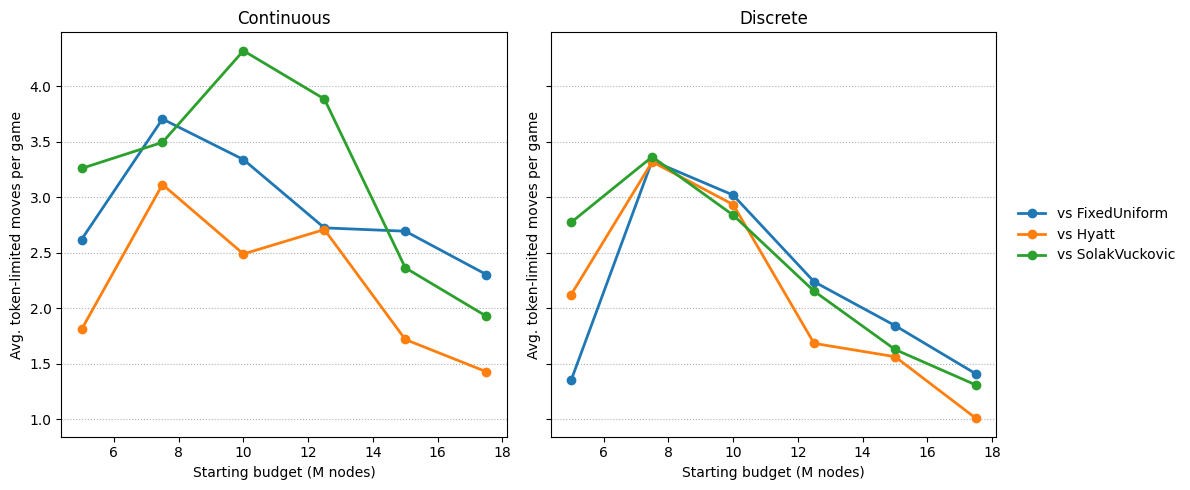

In [58]:
import matplotlib.pyplot as plt

plot_df = tb_summary[tb_summary["budget_value"] < 100].copy()

mode_order = ["continuous", "discrete"]
matchup_order = ["vs FixedUniform", "vs Hyatt", "vs SolakVuckovic"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, mode in zip(axes, mode_order):
    sub_mode = plot_df[plot_df["mode"] == mode]

    for matchup in matchup_order:
        sub = sub_mode[sub_mode["matchup_label"] == matchup].sort_values("budget_value")
        ax.plot(
            sub["budget_value"],
            sub["avg_token_limited_moves"],
            marker="o",
            linewidth=2,
            label=matchup,
        )

    ax.set_title(mode.capitalize())
    ax.set_xlabel("Starting budget (M nodes)")
    ax.set_ylabel("Avg. token-limited moves per game")
    ax.grid(axis="y", linestyle=":")

axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.tight_layout()
plt.show()

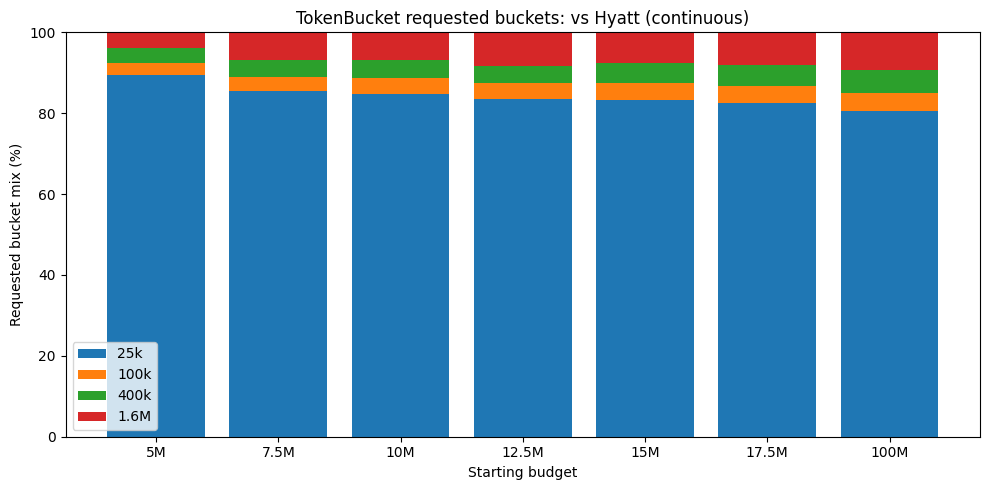

In [59]:
TARGET_MODE = "continuous"
TARGET_MATCHUP = "vs Hyatt"

sub = (
    tb_requests[
        (tb_requests["mode"] == TARGET_MODE) &
        (tb_requests["matchup_label"] == TARGET_MATCHUP)
    ]
    .sort_values("budget_value")
)

x = np.arange(len(sub))
bottom = np.zeros(len(sub))

bucket_cols = [
    ("tb_req_25k_pct", "25k"),
    ("tb_req_100k_pct", "100k"),
    ("tb_req_400k_pct", "400k"),
    ("tb_req_1600k_pct", "1.6M"),
]

plt.figure(figsize=(10, 5))

for col, label in bucket_cols:
    vals = sub[col].to_numpy()
    plt.bar(x, vals, bottom=bottom, label=label)
    bottom += vals

plt.xticks(x, sub["budget_label"])
plt.ylim(0, 100)
plt.xlabel("Starting budget")
plt.ylabel("Requested bucket mix (%)")
plt.title(f"TokenBucket requested buckets: {TARGET_MATCHUP} ({TARGET_MODE})")
plt.legend()
plt.tight_layout()
plt.show()

In [60]:
report_table = tb_summary[
    [
        "budget_label", "mode", "matchup_label",
        "avg_token_limited_moves",
        "pct_games_any_token_limit",
        "avg_req_25k", "avg_req_100k", "avg_req_400k", "avg_req_1600k",
        "avg_budget_remaining", "avg_nodes_total"
    ]
].copy()

report_table

,budget_label,mode,matchup_label,avg_token_limited_moves,pct_games_any_token_limit,avg_req_25k,avg_req_100k,avg_req_400k,avg_req_1600k,avg_budget_remaining,avg_nodes_total
30,5M,continuous,vs FixedUniform,2.620,25.5,42.045,1.570,1.755,2.200,1.722597e+06,3.277529e+06
36,7.5M,continuous,vs FixedUniform,3.705,40.5,41.905,1.945,2.085,4.225,2.986083e+06,4.513956e+06
6,10M,continuous,vs FixedUniform,3.340,40.5,41.595,2.030,2.105,4.410,4.553724e+06,5.446321e+06
12,12.5M,continuous,vs FixedUniform,2.725,33.0,41.270,1.965,2.375,4.295,6.181618e+06,6.318423e+06
18,15M,continuous,vs FixedUniform,2.695,29.5,41.975,1.895,2.375,4.395,8.378123e+06,6.621901e+06
24,17.5M,continuous,vs FixedUniform,2.305,32.0,40.375,2.080,2.530,4.645,9.784288e+06,7.715732e+06
0,100M,continuous,vs FixedUniform,0.000,0.0,39.675,2.310,2.795,4.845,8.991156e+07,1.008844e+07
31,5M,continuous,vs Hyatt,1.810,23.5,42.395,1.385,1.710,1.860,1.873880e+06,3.126222e+06
37,7.5M,continuous,vs Hyatt,3.115,32.5,43.195,1.690,2.165,3.440,3.357257e+06,4.142786e+06
7,10M,continuous,vs Hyatt,2.490,30.0,42.310,1.965,2.175,3.420,4.924406e+06,5.075636e+06


In [63]:
# Pull TokenBucket's token-limited count from whichever side it played
def get_tb_token_limited(row):
    if row["white_policy"] == "TokenBucket":
        return row["white_token_limited_moves"]
    elif row["black_policy"] == "TokenBucket":
        return row["black_token_limited_moves"]
    return np.nan

plot_df = games_df.copy()
plot_df["tb_token_limited_moves"] = plot_df.apply(get_tb_token_limited, axis=1)

# Keep only actual TokenBucket games
plot_df = plot_df[plot_df["tb_token_limited_moves"].notna()].copy()

# Small summary table: aggregate across all matchups
token_limit_summary = (
    plot_df
    .groupby(["budget_label", "budget_value", "mode"])
    .agg(
        games=("tb_token_limited_moves", "size"),
        avg_token_limited_moves=("tb_token_limited_moves", "mean"),
        games_with_any_limit=("tb_token_limited_moves", lambda s: (s > 0).sum()),
    )
    .reset_index()
    .sort_values(["mode", "budget_value"])
)

token_limit_summary["%_games_with_any_limit"] = (
    100 * token_limit_summary["games_with_any_limit"] / token_limit_summary["games"]
)

token_limit_summary.drop(["games"], axis=1)

,budget_label,budget_value,mode,avg_token_limited_moves,games_with_any_limit,%_games_with_any_limit
10,5M,5.0,continuous,2.563333,153,25.500000
12,7.5M,7.5,continuous,3.438333,219,36.500000
2,10M,10.0,continuous,3.383333,230,38.333333
4,12.5M,12.5,continuous,3.106667,224,37.333333
6,15M,15.0,continuous,2.260000,174,29.000000
8,17.5M,17.5,continuous,1.888333,177,29.500000
0,100M,100.0,continuous,0.000000,0,0.000000
11,5M,5.0,discrete,2.085000,183,30.500000
13,7.5M,7.5,discrete,3.338333,205,34.166667
3,10M,10.0,discrete,2.931667,186,31.000000
